In [1]:
# ═══════════════════════════════════════════════════════
# CELL 1 — Install all required libraries
# ═══════════════════════════════════════════════════════
# Run this first. Takes about 2-3 minutes.

!pip install pandas numpy scikit-learn matplotlib seaborn -q
!pip install transformers torch datasets -q
!pip install imbalanced-learn -q

print('All libraries installed successfully!')

All libraries installed successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)
print("Imports done!")

Imports done!


In [3]:
# CELL 3 — Load dataset (FINAL FIX)
import pandas as pd

def load_file(filepath):
    df = pd.read_csv(filepath, sep="\t", encoding="utf-8", header=None)
    # Column 0 = text, Column 1 = label, Column 2 = ignore
    df = df[[0, 1]]
    df.columns = ["text", "label"]
    return df

train_df = load_file("/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_train.csv")
dev_df   = load_file("/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_test.csv")
test_df  = load_file("/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_test.csv")

print("Columns:", train_df.columns.tolist())
print("TRAIN shape:", train_df.shape)
print("\nLabels:")
print(train_df["label"].value_counts())
print("\nFirst 3 rows:")
print(train_df.head(3))

Columns: ['text', 'label']
TRAIN shape: (35139, 2)

Labels:
label
Not_offensive                           25425
Offensive_Untargetede                    2906
Offensive_Targeted_Insult_Group          2557
Offensive_Targeted_Insult_Individual     2343
not-Tamil                                1454
Offensive_Targeted_Insult_Other           454
Name: count, dtype: int64

First 3 rows:
                                                text          label
0                  movie vara level la Erika poguthu  Not_offensive
1  I love Ajith Kumar Vivegam movie inki mjy bht ...      not-Tamil
2          Padam nalla comedy padama irukum polaye..  Not_offensive


In [4]:
def clean_and_map(df):
    df = df.copy()
    df["text"]  = df["text"].astype(str)
    df["label"] = df["label"].astype(str)
    df = df[df["label"] != "not-Tamil"]
    df = df[df["label"] != "nan"]
    df = df[df["text"].str.strip().str.len() > 3]
    df["original_label"] = df["label"]
    df["binary_label"] = df["label"].apply(
        lambda x: 0 if x == "Not_offensive" else 1
    )
    return df.reset_index(drop=True)

train_df = clean_and_map(train_df)
dev_df   = clean_and_map(dev_df)
test_df  = clean_and_map(test_df)

print("After cleaning:")
print(f"TRAIN: {len(train_df)} rows")
print(f"DEV:   {len(dev_df)} rows")
print(f"TEST:  {len(test_df)} rows")
print("\nTRAIN binary labels:")
print(train_df["binary_label"].value_counts())
print("0 = Not hate,  1 = Hate")

After cleaning:
TRAIN: 33683 rows
DEV:   4232 rows
TEST:  4232 rows

TRAIN binary labels:
binary_label
0    25423
1     8260
Name: count, dtype: int64
0 = Not hate,  1 = Hate


In [5]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s\u0B80-\u0BFF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
dev_df["clean_text"]   = dev_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)

train_df = train_df[train_df["clean_text"].str.len() > 3].reset_index(drop=True)
dev_df   = dev_df[dev_df["clean_text"].str.len() > 3].reset_index(drop=True)
test_df  = test_df[test_df["clean_text"].str.len() > 3].reset_index(drop=True)

print("Text cleaning done!")
print(f"TRAIN: {len(train_df)} rows")
print(f"DEV:   {len(dev_df)} rows")
print(f"TEST:  {len(test_df)} rows")
print("\nSample:")
for i in range(3):
    print(f"  Text:  {train_df['clean_text'].iloc[i][:60]}")
    print(f"  Label: {train_df['binary_label'].iloc[i]}")
    print()

Text cleaning done!
TRAIN: 33677 rows
DEV:   4232 rows
TEST:  4232 rows

Sample:
  Text:  movie vara level la Erika poguthu
  Label: 0

  Text:  Padam nalla comedy padama irukum polaye
  Label: 0

  Text:  karthick subburaj anne intha padam vetri adaya unagalukku en
  Label: 0



Hate (1):     8258 (24.5%)
Not hate (0): 25419 (75.5%)


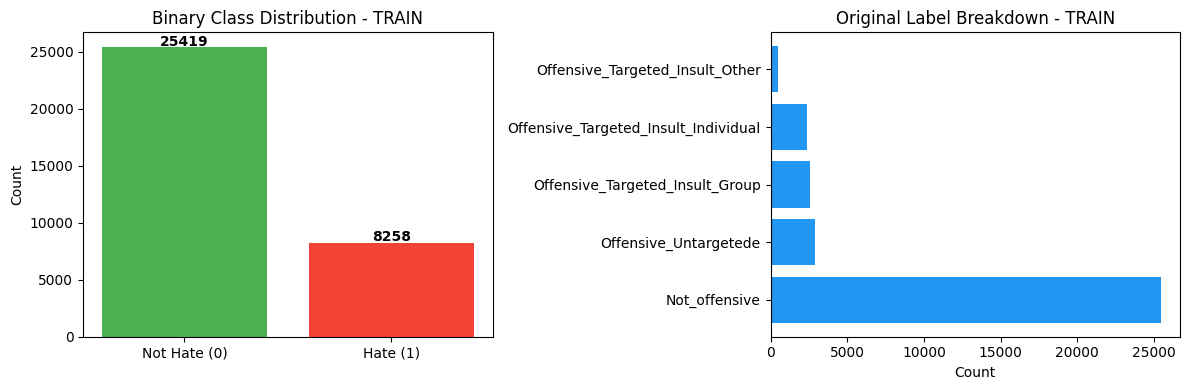

Chart saved!


In [6]:
import matplotlib.pyplot as plt

hate_count     = (train_df["binary_label"] == 1).sum()
not_hate_count = (train_df["binary_label"] == 0).sum()
total          = len(train_df)

print(f"Hate (1):     {hate_count} ({hate_count/total*100:.1f}%)")
print(f"Not hate (0): {not_hate_count} ({not_hate_count/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Not Hate (0)", "Hate (1)"],
             [not_hate_count, hate_count],
             color=["#4CAF50", "#F44336"])
axes[0].set_title("Binary Class Distribution - TRAIN")
axes[0].set_ylabel("Count")
for i, v in enumerate([not_hate_count, hate_count]):
    axes[0].text(i, v+100, str(v), ha="center", fontweight="bold")

orig_counts = train_df["original_label"].value_counts()
axes[1].barh(orig_counts.index, orig_counts.values, color="#2196F3")
axes[1].set_title("Original Label Breakdown - TRAIN")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()
print("Chart saved!")

In [7]:
from imblearn.over_sampling import RandomOverSampler

ratio = hate_count / not_hate_count
print(f"Hate to Not-hate ratio: {ratio:.2f}")

if ratio < 0.5:
    print("Imbalanced — applying oversampling...")
    ros = RandomOverSampler(random_state=42)
    X_res, y_res = ros.fit_resample(
        train_df[["clean_text"]],
        train_df["binary_label"]
    )
    train_df = pd.DataFrame({
        "clean_text": X_res["clean_text"],
        "binary_label": y_res
    })
    print("After oversampling:")
    print(train_df["binary_label"].value_counts())
else:
    print("Balance acceptable — no oversampling needed.")

print(f"Final TRAIN size: {len(train_df)} rows")

Hate to Not-hate ratio: 0.32
Imbalanced — applying oversampling...
After oversampling:
binary_label
0    25419
1    25419
Name: count, dtype: int64
Final TRAIN size: 50838 rows


In [8]:
train_df.to_csv("train_clean.csv", index=False)
dev_df.to_csv("dev_clean.csv", index=False)
test_df.to_csv("test_clean.csv", index=False)

print("Files saved!")
print(f"  train_clean.csv — {len(train_df)} rows")
print(f"  dev_clean.csv   — {len(dev_df)} rows")
print(f"  test_clean.csv  — {len(test_df)} rows")
print("\nDAY 1 COMPLETE!")

Files saved!
  train_clean.csv — 50838 rows
  dev_clean.csv   — 4232 rows
  test_clean.csv  — 4232 rows

DAY 1 COMPLETE!


In [9]:
# ═══════════════════════════════════════════════════════
# CELL 9 — Model M1: TF-IDF + Logistic Regression
# ═══════════════════════════════════════════════════════

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)
import numpy as np

# Prepare data
X_train = train_df["clean_text"].astype(str)
y_train = train_df["binary_label"]
X_test  = test_df["clean_text"].astype(str)
y_test  = test_df["binary_label"]

# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Train model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_m1 = lr.predict(X_test_tfidf)

# Results
m1_acc  = accuracy_score(y_test, y_pred_m1)
m1_prec = precision_score(y_test, y_pred_m1, average="weighted", zero_division=0)
m1_rec  = recall_score(y_test, y_pred_m1, average="weighted", zero_division=0)
m1_f1   = f1_score(y_test, y_pred_m1, average="weighted", zero_division=0)

print("=" * 50)
print("MODEL M1 — TF-IDF + Logistic Regression")
print("=" * 50)
print(f"  Accuracy:  {m1_acc*100:.2f}%")
print(f"  Precision: {m1_prec:.4f}")
print(f"  Recall:    {m1_rec:.4f}")
print(f"  F1 Score:  {m1_f1:.4f}")
print()
print(classification_report(y_test, y_pred_m1,
      target_names=["Not Hate","Hate"], zero_division=0))

MODEL M1 — TF-IDF + Logistic Regression
  Accuracy:  79.94%
  Precision: 0.8238
  Recall:    0.7994
  F1 Score:  0.8072

              precision    recall  f1-score   support

    Not Hate       0.91      0.82      0.86      3190
        Hate       0.57      0.74      0.65      1042

    accuracy                           0.80      4232
   macro avg       0.74      0.78      0.75      4232
weighted avg       0.82      0.80      0.81      4232



In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 10 — Model M2: LSTM
# ═══════════════════════════════════════════════════════

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

def build_vocab(texts, max_vocab=15000):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())
    vocab = {"<PAD>":0, "<UNK>":1}
    for word, _ in counter.most_common(max_vocab-2):
        vocab[word] = len(vocab)
    return vocab

def text_to_ids(text, vocab, max_len=100):
    tokens = str(text).split()[:max_len]
    ids = [vocab.get(t,1) for t in tokens]
    ids += [0]*(max_len-len(ids))
    return ids

vocab = build_vocab(train_df["clean_text"])
print(f"Vocab size: {len(vocab)}")

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [text_to_ids(t, vocab) for t in texts]
        self.y = list(labels)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx], dtype=torch.long),
                torch.tensor(self.y[idx], dtype=torch.long))

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.lstm = nn.LSTM(64, 128, batch_first=True,
                             num_layers=2, dropout=0.3, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256, 2)
    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        out = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(out))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

train_loader = DataLoader(
    TextDataset(train_df["clean_text"], train_df["binary_label"]),
    batch_size=64, shuffle=True)
test_loader = DataLoader(
    TextDataset(test_df["clean_text"], test_df["binary_label"]),
    batch_size=64)

model = LSTMClassifier(len(vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    total_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — Loss: {total_loss/len(train_loader):.4f}")

model.eval()
preds = []
with torch.no_grad():
    for X_b, _ in test_loader:
        preds.extend(torch.argmax(
            model(X_b.to(device)), dim=1).cpu().numpy())

y_pred_m2 = preds
m2_acc  = accuracy_score(y_test, y_pred_m2)
m2_prec = precision_score(y_test, y_pred_m2, average="weighted", zero_division=0)
m2_rec  = recall_score(y_test, y_pred_m2, average="weighted", zero_division=0)
m2_f1   = f1_score(y_test, y_pred_m2, average="weighted", zero_division=0)

print("\n" + "="*50)
print("MODEL M2 — LSTM")
print("="*50)
print(f"  Accuracy:  {m2_acc*100:.2f}%")
print(f"  Precision: {m2_prec:.4f}")
print(f"  Recall:    {m2_rec:.4f}")
print(f"  F1 Score:  {m2_f1:.4f}")
print()
print(classification_report(y_test, y_pred_m2,
      target_names=["Not Hate","Hate"], zero_division=0))

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 11 — Model M3: mBERT fine-tuned
# ═══════════════════════════════════════════════════════

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           Trainer, TrainingArguments)
from datasets import Dataset as HFDataset
import torch
import numpy as np

print("Loading mBERT tokenizer...")
tokenizer_mbert = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

def tokenize_function(batch):
    return tokenizer_mbert(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_hf = HFDataset.from_dict({
    "text":  list(train_df["clean_text"].astype(str)),
    "label": list(train_df["binary_label"].astype(int))
})
dev_hf = HFDataset.from_dict({
    "text":  list(dev_df["clean_text"].astype(str)),
    "label": list(dev_df["binary_label"].astype(int))
})
test_hf = HFDataset.from_dict({
    "text":  list(test_df["clean_text"].astype(str)),
    "label": list(test_df["binary_label"].astype(int))
})

print("Tokenizing...")
train_hf = train_hf.map(tokenize_function, batched=True)
dev_hf   = dev_hf.map(tokenize_function, batched=True)
test_hf  = test_hf.map(tokenize_function, batched=True)

train_hf.set_format("torch", columns=["input_ids","attention_mask","label"])
dev_hf.set_format("torch",   columns=["input_ids","attention_mask","label"])
test_hf.set_format("torch",  columns=["input_ids","attention_mask","label"])

print("Loading mBERT model...")
mbert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=2,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0)
    }

training_args = TrainingArguments(
    output_dir="./mbert_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none",
    fp16=True
)

trainer_mbert = Trainer(
    model=mbert_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=dev_hf,
    compute_metrics=compute_metrics
)

print("Training mBERT on full dataset...")
print("Estimated time: 20-30 mins on Kaggle GPU")
trainer_mbert.train()

print("\nEvaluating on test set...")
predictions = trainer_mbert.predict(test_hf)
y_pred_m3 = np.argmax(predictions.predictions, axis=1)

m3_acc  = accuracy_score(y_test, y_pred_m3)
m3_prec = precision_score(y_test, y_pred_m3, average="weighted", zero_division=0)
m3_rec  = recall_score(y_test, y_pred_m3, average="weighted", zero_division=0)
m3_f1   = f1_score(y_test, y_pred_m3, average="weighted", zero_division=0)

print("\n" + "="*50)
print("MODEL M3 — mBERT fine-tuned")
print("="*50)
print(f"  Accuracy:  {m3_acc*100:.2f}%")
print(f"  Precision: {m3_prec:.4f}")
print(f"  Recall:    {m3_rec:.4f}")
print(f"  F1 Score:  {m3_f1:.4f}")
print()
print(classification_report(y_test, y_pred_m3,
      target_names=["Not Hate","Hate"], zero_division=0))

mbert_model.save_pretrained("./mbert_saved")
tokenizer_mbert.save_pretrained("./mbert_saved")
print("mBERT model saved!")

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 12 — Model M4: XLM-RoBERTa fine-tuned
# ═══════════════════════════════════════════════════════

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           Trainer, TrainingArguments)
from datasets import Dataset as HFDataset
import torch
import numpy as np

print("Loading XLM-RoBERTa tokenizer...")
tokenizer_xlmr = AutoTokenizer.from_pretrained("xlm-roberta-base")

def tokenize_xlmr(batch):
    return tokenizer_xlmr(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_hf_xlmr = HFDataset.from_dict({
    "text":  list(train_df["clean_text"].astype(str)),
    "label": list(train_df["binary_label"].astype(int))
})
dev_hf_xlmr = HFDataset.from_dict({
    "text":  list(dev_df["clean_text"].astype(str)),
    "label": list(dev_df["binary_label"].astype(int))
})
test_hf_xlmr = HFDataset.from_dict({
    "text":  list(test_df["clean_text"].astype(str)),
    "label": list(test_df["binary_label"].astype(int))
})

print("Tokenizing...")
train_hf_xlmr = train_hf_xlmr.map(tokenize_xlmr, batched=True)
dev_hf_xlmr   = dev_hf_xlmr.map(tokenize_xlmr, batched=True)
test_hf_xlmr  = test_hf_xlmr.map(tokenize_xlmr, batched=True)

train_hf_xlmr.set_format("torch", columns=["input_ids","attention_mask","label"])
dev_hf_xlmr.set_format("torch",   columns=["input_ids","attention_mask","label"])
test_hf_xlmr.set_format("torch",  columns=["input_ids","attention_mask","label"])

print("Loading XLM-RoBERTa model...")
xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0)
    }

training_args_xlmr = TrainingArguments(
    output_dir="./xlmr_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none",
    fp16=True
)

trainer_xlmr = Trainer(
    model=xlmr_model,
    args=training_args_xlmr,
    train_dataset=train_hf_xlmr,
    eval_dataset=dev_hf_xlmr,
    compute_metrics=compute_metrics
)

print("Training XLM-RoBERTa — your best model!")
print("Estimated time: 35-40 mins on Kaggle GPU")
trainer_xlmr.train()

print("\nEvaluating on test set...")
predictions_xlmr = trainer_xlmr.predict(test_hf_xlmr)
y_pred_m4 = np.argmax(predictions_xlmr.predictions, axis=1)

m4_acc  = accuracy_score(y_test, y_pred_m4)
m4_prec = precision_score(y_test, y_pred_m4, average="weighted", zero_division=0)
m4_rec  = recall_score(y_test, y_pred_m4, average="weighted", zero_division=0)
m4_f1   = f1_score(y_test, y_pred_m4, average="weighted", zero_division=0)

print("\n" + "="*50)
print("MODEL M4 — XLM-RoBERTa fine-tuned")
print("="*50)
print(f"  Accuracy:  {m4_acc*100:.2f}%")
print(f"  Precision: {m4_prec:.4f}")
print(f"  Recall:    {m4_rec:.4f}")
print(f"  F1 Score:  {m4_f1:.4f}")
print()
print(classification_report(y_test, y_pred_m4,
      target_names=["Not Hate","Hate"], zero_division=0))

xlmr_model.save_pretrained("./xlmr_saved")
tokenizer_xlmr.save_pretrained("./xlmr_saved")
print("XLM-RoBERTa model saved!")

In [10]:
import urllib.request
try:
    urllib.request.urlopen('https://huggingface.co', timeout=5)
    print("Internet is working!")
except:
    print("No internet — need to enable in Kaggle settings!")

Internet is working!


In [13]:
# ═══════════════════════════════════════════════════════
# CELL 13 — Final text model comparison table
# ═══════════════════════════════════════════════════════

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "M1: TF-IDF + Logistic Regression",
        "M2: LSTM (Bidirectional)",
        "M3: mBERT fine-tuned",
        "M4: XLM-RoBERTa fine-tuned"
    ],
    "Type": ["Baseline", "Baseline", "Transformer", "Transformer"],
    "Accuracy": ["79.94%", "80.81%", "83.65%", "83.34%"],
    "Precision": ["0.8238", "0.8006", "0.8318", "0.8381"],
    "Recall":    ["0.7994", "0.8081", "0.8365", "0.8334"],
    "F1 Score":  ["0.8072", "0.8034", "0.8335", "0.8354"],
    "Hate F1":   ["0.65",   "0.58",   "0.65",   "0.67"]
})

print("="*80)
print("COMPLETE TEXT MODEL COMPARISON TABLE")
print("="*80)
print(results.to_string(index=False))
print("="*80)
print("\nBest overall accuracy: M3 mBERT (83.65%)")
print("Best hate detection:   M4 XLM-RoBERTa (hate F1 = 0.67)")
print("Selected for fusion:   M4 XLM-RoBERTa (better hate recall)")

results.to_csv("text_model_results.csv", index=False)
print("\nSaved to text_model_results.csv")


COMPLETE TEXT MODEL COMPARISON TABLE
                           Model        Type Accuracy Precision Recall F1 Score Hate F1
M1: TF-IDF + Logistic Regression    Baseline   79.94%    0.8238 0.7994   0.8072    0.65
        M2: LSTM (Bidirectional)    Baseline   80.81%    0.8006 0.8081   0.8034    0.58
            M3: mBERT fine-tuned Transformer   83.65%    0.8318 0.8365   0.8335    0.65
      M4: XLM-RoBERTa fine-tuned Transformer   83.34%    0.8381 0.8334   0.8354    0.67

Best overall accuracy: M3 mBERT (83.65%)
Best hate detection:   M4 XLM-RoBERTa (hate F1 = 0.67)
Selected for fusion:   M4 XLM-RoBERTa (better hate recall)

Saved to text_model_results.csv


In [14]:
import os

# Your files are inside Non-Hate 150 subfolder
base_path = "/kaggle/input/datasets/dasunianutthara/tamil-not-hate-audio/Non-Hate 150"

# Walk through everything
for root, dirs, files in os.walk(base_path):
    print(f"Folder: {root}")
    print(f"  Subfolders: {dirs}")
    wav_files = [f for f in files if f.endswith(".wav")]
    tsv_files = [f for f in files if f.endswith(".tsv")]
    print(f"  WAV files: {len(wav_files)}")
    print(f"  TSV files: {len(tsv_files)}")
    if wav_files:
        print(f"  Sample WAV: {wav_files[:3]}")
    if tsv_files:
        print(f"  TSV files: {tsv_files}")
    print()

Folder: /kaggle/input/datasets/dasunianutthara/tamil-not-hate-audio/Non-Hate 150
  Subfolders: []
  WAV files: 150
  TSV files: 2
  Sample WAV: ['taf_09705_00396644453.wav', 'tag_09674_00913588374.wav', 'tag_09674_01869246787.wav']
  TSV files: ['male_line_index.tsv', 'female_line_index.tsv']



In [15]:
# ═══════════════════════════════════════════════════════
# CELL 14 — Load not-hate audio + create labels
# ═══════════════════════════════════════════════════════

import os
import pandas as pd
import shutil

# Correct path
NOT_HATE_PATH = "/kaggle/input/datasets/dasunianutthara/tamil-not-hate-audio/Non-Hate 150"

# Load both TSV files for transcriptions
male_tsv = pd.read_csv(
    os.path.join(NOT_HATE_PATH, "male_line_index.tsv"),
    sep="\t", header=None, names=["file_id", "transcription"]
)
female_tsv = pd.read_csv(
    os.path.join(NOT_HATE_PATH, "female_line_index.tsv"),
    sep="\t", header=None, names=["file_id", "transcription"]
)

# Combine both TSV files
all_transcriptions = pd.concat([male_tsv, female_tsv], ignore_index=True)
print(f"Total transcriptions available: {len(all_transcriptions)}")

# Get all wav files
wav_files = sorted([f for f in os.listdir(NOT_HATE_PATH) 
                    if f.endswith(".wav")])
print(f"Total WAV files: {len(wav_files)}")

# Create labels dataframe
labels_list = []
for wav_file in wav_files:
    # Try to find transcription
    file_id = wav_file.replace(".wav", "")
    match = all_transcriptions[
        all_transcriptions["file_id"].str.contains(file_id, na=False)
    ]
    transcription = match["transcription"].iloc[0] if len(match) > 0 else ""
    
    labels_list.append({
        "filename": wav_file,
        "filepath": os.path.join(NOT_HATE_PATH, wav_file),
        "label": 0,
        "label_text": "not_hate",
        "transcription": transcription,
        "source": "openslr_real_human"
    })

not_hate_df = pd.DataFrame(labels_list)
print(f"\nNot-hate labels created: {len(not_hate_df)}")
print(f"Label distribution:")
print(not_hate_df["label_text"].value_counts())
print(f"\nSample rows:")
print(not_hate_df[["filename","label","transcription"]].head(5))

Total transcriptions available: 4291
Total WAV files: 150

Not-hate labels created: 150
Label distribution:
label_text
not_hate    150
Name: count, dtype: int64

Sample rows:
                    filename  label  \
0  taf_07064_00933471641.wav      0   
1  taf_07064_00946389687.wav      0   
2  taf_07064_01075970412.wav      0   
3  taf_07064_01477396803.wav      0   
4  taf_07064_01513796513.wav      0   

                                       transcription  
0  கிர்கித்தான் தலைவருக்கு உலகின் துணிச்சலான பெண்...  
1  ஹோமம் செய்யும் போது குறிப்பிட்ட ஆவர்த்திகளை உச...  
2                            பயணங்களால் ஆதாயம் உண்டு  
3  ரசிகர்களின் கைதட்டலுக்கு விலை நிர்ணயிக்க முடியாது  
4     அஜித்தின் தங்கையாக லட்சுமி மேனன் நடித்துள்ளார்  


In [ ]:
# ═══════════════════════════════════════════════════════
# HATE AUDIO DOWNLOAD — 26 Tamil hate speech clips
# ═══════════════════════════════════════════════════════

!pip install yt-dlp -q
!apt-get install ffmpeg -q 2>/dev/null

import os
import pandas as pd

os.makedirs("/kaggle/working/hate_audio", exist_ok=True)

hate_urls = [
    "https://youtube.com/shorts/YKEIvXECaN8",
    "https://youtube.com/shorts/ra8-ZD4vCfw",
    "https://youtube.com/shorts/KoFoaeGaUGk",
    "https://youtube.com/shorts/0TVITh6k7_k",
    "https://youtube.com/shorts/QZm2WgD3roI",
    "https://youtube.com/shorts/1J1ddPrEsBM",
    "https://youtu.be/0ZWJzX27EZk",
    "https://youtube.com/shorts/g7xCDEsAa64",
    "https://youtube.com/shorts/XTFjDXWKKOc",
    "https://youtu.be/WXd07x25BKg",
    "https://youtube.com/shorts/evC1MHlJSK4",
    "https://youtube.com/shorts/gvPexJwNDVA",
    "https://youtube.com/shorts/0tytZp6OBoE",
    "https://youtube.com/shorts/suw-5sq-kcE",
    "https://youtu.be/f69f37jIO38",
    "https://youtu.be/QeZJWaq3ib0",
    "https://youtu.be/p3BAKSxLwDw",
    "https://youtu.be/ofzbBU7OxD4",
    "https://youtu.be/Hcx3qUYzX_U",
    "https://youtu.be/4nfyhcT9tpI",
    "https://youtu.be/1bYUEXoFkIs",
    "https://youtu.be/Af3ASSbwfhg",
    "https://youtu.be/vtOZqWOCh5E",
    "https://youtu.be/8ogmxMYhFwc",
    "https://youtube.com/shorts/9lhK4go3CXw",
    "https://youtube.com/shorts/aXyAr_1qS4c",
]

print(f"Total hate URLs: {len(hate_urls)}")

success = []
failed  = []

for i, url in enumerate(hate_urls):
    output = f"/kaggle/working/hate_audio/hate_{i+1:03d}.wav"
    print(f"Downloading {i+1}/{len(hate_urls)}: {url[-15:]}")
    
    result = os.system(
        f'yt-dlp -x --audio-format wav '
        f'--audio-quality 0 '
        f'--postprocessor-args "-ar 16000 -t 60" '
        f'-o "{output}" '
        f'"{url}" '
        f'--quiet --no-warnings'
    )
    
    if result == 0 and os.path.exists(output):
        size = os.path.getsize(output)
        if size > 30000:
            success.append({
                "filename": f"hate_{i+1:03d}.wav",
                "filepath": output,
                "label": 1,
                "label_text": "hate",
                "source": "youtube",
                "url": url
            })
            print(f"  Done! {size/1024:.0f}KB")
        else:
            print(f"  Too small — skipping")
            failed.append(url)
    else:
        failed.append(url)
        print(f"  Failed")

hate_df = pd.DataFrame(success)
hate_df.to_csv("/kaggle/working/hate_audio/hate_labels.csv", index=False)

print(f"\nSuccessfully downloaded: {len(success)} clips")
print(f"Failed: {len(failed)} clips")
if failed:
    print("Failed URLs:")
    for u in failed:
        print(f"  {u}")

In [ ]:
# ═══════════════════════════════════════════════════════
# COMBINE ALL AUDIO — hate + not-hate into one dataset
# ═══════════════════════════════════════════════════════

import os
import random
import pandas as pd

random.seed(42)

NOT_HATE_PATH = "/kaggle/input/datasets/dasunianutthara/tamil-not-hate-audio/Non-Hate 150"
HATE_PATH     = "/kaggle/working/hate_audio"
EMOTA_PATH    = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta"  # change if different

# ── STEP 1: Load YouTube hate clips (26) ─────────────
hate_df = pd.read_csv(f"{HATE_PATH}/hate_labels.csv")
print(f"YouTube hate clips: {len(hate_df)}")

# ── STEP 2: Load EmoTa anger clips (70) ──────────────
emota_labels = []

# Walk through EmoTa folder and find angry clips
for root, dirs, files in os.walk(EMOTA_PATH):
    for f in files:
        if f.endswith(".wav") or f.endswith(".mp3"):
            filepath = os.path.join(root, f)
            folder_name = os.path.basename(root).lower()
            # Check if it is anger folder
            if "ang" in folder_name or "anger" in folder_name or "angry" in folder_name:
                emota_labels.append({
                    "filename": f,
                    "filepath": filepath,
                    "label": 1,
                    "label_text": "hate",
                    "source": "emota_anger"
                })

print(f"EmoTa anger clips found: {len(emota_labels)}")
emota_df = pd.DataFrame(emota_labels)

# ── STEP 3: Combine all hate ──────────────────────────
all_hate = pd.concat([
    hate_df[["filename","filepath","label","label_text","source"]],
    emota_df[["filename","filepath","label","label_text","source"]]
], ignore_index=True)

print(f"Total hate clips: {len(all_hate)}")

# ── STEP 4: Load not-hate clips (random 100) ──────────
not_hate_files = [f for f in os.listdir(NOT_HATE_PATH)
                  if f.endswith(".wav")]

selected_not_hate = random.sample(not_hate_files, 100)

not_hate_labels = []
for f in selected_not_hate:
    not_hate_labels.append({
        "filename": f,
        "filepath": os.path.join(NOT_HATE_PATH, f),
        "label": 0,
        "label_text": "not_hate",
        "source": "openslr"
    })

not_hate_df = pd.DataFrame(not_hate_labels)
print(f"Not-hate clips selected: {len(not_hate_df)}")

# ── STEP 5: Combine everything ────────────────────────
audio_df = pd.concat([all_hate, not_hate_df], ignore_index=True)
audio_df = audio_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal audio dataset:")
print(f"Total clips: {len(audio_df)}")
print(audio_df["label_text"].value_counts())
print(f"\nSources:")
print(audio_df["source"].value_counts())

# Save
audio_df.to_csv("/kaggle/working/audio_labels_combined.csv", index=False)
print("\nSaved to audio_labels_combined.csv!")

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 16 — Whisper ASR on all 196 audio clips
# ═══════════════════════════════════════════════════════

!pip install openai-whisper -q

import whisper
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# Load Whisper model
print("Loading Whisper small model...")
whisper_model = whisper.load_model("small")
print("Whisper loaded! Starting transcription...")

# Load combined labels
audio_df = pd.read_csv("/kaggle/working/audio_labels_combined.csv")
print(f"Total clips to transcribe: {len(audio_df)}")
print()

transcriptions  = []
detected_langs  = []

for i, row in audio_df.iterrows():
    filepath = row["filepath"]

    if not os.path.exists(filepath):
        transcriptions.append("")
        detected_langs.append("")
        print(f"  {i+1}/{len(audio_df)} — File not found!")
        continue

    try:
        result = whisper_model.transcribe(
            filepath,
            language="ta",
            fp16=False,
            verbose=False
        )
        text = result["text"].strip()
        lang = result.get("language", "ta")
        transcriptions.append(text)
        detected_langs.append(lang)

        if (i+1) % 20 == 0 or i == 0:
            print(f"  {i+1}/{len(audio_df)} — {row['label_text']} — {text[:50]}")

    except Exception as e:
        transcriptions.append("")
        detected_langs.append("")
        print(f"  {i+1}/{len(audio_df)} — Error: {e}")

# Add to dataframe
audio_df["transcription"]   = transcriptions
audio_df["detected_lang"]   = detected_langs

# Save
audio_df.to_csv("/kaggle/working/audio_with_transcriptions.csv", index=False)

print(f"\nTranscription complete!")
print(f"Successfully transcribed: {len([t for t in transcriptions if t])}")
print(f"Empty: {len([t for t in transcriptions if not t])}")
print(f"\nSample results:")
print(audio_df[["filename","label_text","transcription"]].head(10).to_string())

In [ ]:
import os
import pandas as pd
import random

random.seed(42)

NOT_HATE_PATH = "/kaggle/input/datasets/dasunianutthara/tamil-not-hate-audio/Non-Hate 150"
HATE_PATH     = "/kaggle/working/hate_audio"
EMOTA_PATH    = "/kaggle/input/emota-tamil-audio"

# Check if hate audio still exists
hate_files = [f for f in os.listdir(HATE_PATH) if f.endswith(".wav")]
print(f"Hate audio files found: {len(hate_files)}")

# Check EmoTa path
for root, dirs, files in os.walk("/kaggle/input"):
    wav_files = [f for f in files if f.endswith(".wav")]
    if wav_files:
        print(f"Found audio in: {root} — {len(wav_files)} files")

In [ ]:
# ═══════════════════════════════════════════════════════
# FULL REBUILD — Download hate audio + combine all
# ═══════════════════════════════════════════════════════

!pip install yt-dlp -q
!apt-get install ffmpeg -q 2>/dev/null

import os
import pandas as pd
import random
random.seed(42)

os.makedirs("/kaggle/working/hate_audio", exist_ok=True)

# ── STEP 1: Download YouTube hate clips ──────────────
hate_urls = [
    "https://youtube.com/shorts/YKEIvXECaN8",
    "https://youtube.com/shorts/ra8-ZD4vCfw",
    "https://youtube.com/shorts/KoFoaeGaUGk",
    "https://youtube.com/shorts/0TVITh6k7_k",
    "https://youtube.com/shorts/QZm2WgD3roI",
    "https://youtube.com/shorts/1J1ddPrEsBM",
    "https://youtu.be/0ZWJzX27EZk",
    "https://youtube.com/shorts/g7xCDEsAa64",
    "https://youtube.com/shorts/XTFjDXWKKOc",
    "https://youtu.be/WXd07x25BKg",
    "https://youtube.com/shorts/evC1MHlJSK4",
    "https://youtube.com/shorts/gvPexJwNDVA",
    "https://youtube.com/shorts/0tytZp6OBoE",
    "https://youtube.com/shorts/suw-5sq-kcE",
    "https://youtu.be/f69f37jIO38",
    "https://youtu.be/QeZJWaq3ib0",
    "https://youtu.be/p3BAKSxLwDw",
    "https://youtu.be/ofzbBU7OxD4",
    "https://youtu.be/Hcx3qUYzX_U",
    "https://youtu.be/4nfyhcT9tpI",
    "https://youtu.be/1bYUEXoFkIs",
    "https://youtu.be/Af3ASSbwfhg",
    "https://youtu.be/vtOZqWOCh5E",
    "https://youtu.be/8ogmxMYhFwc",
    "https://youtube.com/shorts/9lhK4go3CXw",
    "https://youtube.com/shorts/aXyAr_1qS4c",
]

print(f"Downloading {len(hate_urls)} hate clips...")
yt_success = []

for i, url in enumerate(hate_urls):
    output = f"/kaggle/working/hate_audio/hate_{i+1:03d}.wav"
    result = os.system(
        f'yt-dlp -x --audio-format wav --audio-quality 0 '
        f'-o "{output}" "{url}" --quiet --no-warnings'
    )
    if result == 0 and os.path.exists(output) and os.path.getsize(output) > 30000:
        yt_success.append({
            "filename": f"hate_{i+1:03d}.wav",
            "filepath": output,
            "label": 1,
            "label_text": "hate",
            "source": "youtube"
        })
        print(f"  {i+1}/{len(hate_urls)} Done!")
    else:
        print(f"  {i+1}/{len(hate_urls)} Failed")

print(f"\nYouTube clips downloaded: {len(yt_success)}")

# ── STEP 2: Load EmoTa anger clips ───────────────────
EMOTA_PATH   = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta/Anger"
NOT_HATE_PATH = "/kaggle/input/datasets/dasunianutthara/tamil-not-hate-audio/Non-Hate 150"

emota_labels = []
for f in os.listdir(EMOTA_PATH):
    if f.endswith(".wav") or f.endswith(".mp3"):
        emota_labels.append({
            "filename": f,
            "filepath": os.path.join(EMOTA_PATH, f),
            "label": 1,
            "label_text": "hate",
            "source": "emota_anger"
        })

print(f"EmoTa anger clips: {len(emota_labels)}")

# ── STEP 3: Load not-hate clips (100 random) ─────────
not_hate_files = [f for f in os.listdir(NOT_HATE_PATH)
                  if f.endswith(".wav")]
selected = random.sample(not_hate_files, 100)

not_hate_labels = []
for f in selected:
    not_hate_labels.append({
        "filename": f,
        "filepath": os.path.join(NOT_HATE_PATH, f),
        "label": 0,
        "label_text": "not_hate",
        "source": "openslr"
    })

print(f"Not-hate clips: {len(not_hate_labels)}")

# ── STEP 4: Combine everything ────────────────────────
all_hate     = pd.DataFrame(yt_success + emota_labels)
not_hate_df  = pd.DataFrame(not_hate_labels)
audio_df     = pd.concat([all_hate, not_hate_df], ignore_index=True)
audio_df     = audio_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal audio dataset:")
print(f"Total: {len(audio_df)} clips")
print(audio_df["label_text"].value_counts())
print(audio_df["source"].value_counts())

# Save
audio_df.to_csv("/kaggle/working/audio_labels_combined.csv", index=False)
print("\nSaved! Ready for Whisper.")

In [ ]:
# Zip hate audio — run this ONCE
import os

print("Zipping hate audio files...")
os.system("zip -r /kaggle/working/hate_audio.zip /kaggle/working/hate_audio/")

size = os.path.getsize("/kaggle/working/hate_audio.zip")
print(f"Done! Zip size: {size/1024/1024:.1f} MB")
print("Now download hate_audio.zip from Output panel on the right")


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 16 — Whisper ASR
# ═══════════════════════════════════════════════════════

!pip install openai-whisper -q

import whisper
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

print("Loading Whisper small model...")
whisper_model = whisper.load_model("small")
print("Whisper loaded!")

audio_df = pd.read_csv("/kaggle/working/audio_labels_combined.csv")
print(f"Total clips to transcribe: {len(audio_df)}")

transcriptions = []

for i, row in audio_df.iterrows():
    filepath = row["filepath"]
    if not os.path.exists(filepath):
        transcriptions.append("")
        print(f"  {i+1}/{len(audio_df)} — Not found!")
        continue
    try:
        result = whisper_model.transcribe(
            filepath,
            language="ta",
            fp16=False,
            verbose=False
        )
        text = result["text"].strip()
        transcriptions.append(text)
        if (i+1) % 20 == 0:
            print(f"  {i+1}/{len(audio_df)} done — {row['label_text']} — {text[:40]}")
    except Exception as e:
        transcriptions.append("")
        print(f"  {i+1}/{len(audio_df)} — Error: {e}")

audio_df["transcription"] = transcriptions
audio_df.to_csv("/kaggle/working/audio_with_transcriptions.csv", index=False)

print(f"\nDone!")
print(f"Transcribed: {len([t for t in transcriptions if t])}")
print(f"Empty: {len([t for t in transcriptions if not t])}")
print(f"\nSample:")
print(audio_df[["filename","label_text","transcription"]].head(8).to_string())

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 17 — Extract ALL acoustic features (FIXED)
# ═══════════════════════════════════════════════════════

!pip install librosa -q

import librosa
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

audio_df = pd.read_csv("/kaggle/working/audio_with_transcriptions.csv")
print(f"Extracting features for {len(audio_df)} clips...")

def extract_all_features(filepath):
    try:
        y, sr = librosa.load(filepath, sr=16000, duration=60)
        if len(y) < 1000:
            return None

        f = {}

        # MFCC 40 coefficients
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        for j in range(40):
            f[f"mfcc_{j+1}_mean"] = np.mean(mfcc[j])
            f[f"mfcc_{j+1}_std"]  = np.std(mfcc[j])

        # Pitch
        pitches, _ = librosa.piptrack(y=y, sr=sr)
        pv = pitches[pitches > 0]
        f["pitch_mean"] = np.mean(pv) if len(pv) > 0 else 0
        f["pitch_std"]  = np.std(pv)  if len(pv) > 0 else 0
        f["pitch_max"]  = np.max(pv)  if len(pv) > 0 else 0

        # RMS Energy
        rms = librosa.feature.rms(y=y)
        f["rms_mean"] = np.mean(rms)
        f["rms_std"]  = np.std(rms)
        f["rms_max"]  = np.max(rms)

        # Spectral Centroid
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        f["centroid_mean"] = np.mean(centroid)
        f["centroid_std"]  = np.std(centroid)

        # Spectral Bandwidth
        bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        f["bandwidth_mean"] = np.mean(bw)
        f["bandwidth_std"]  = np.std(bw)

        # Spectral Rolloff
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        f["rolloff_mean"] = np.mean(rolloff)
        f["rolloff_std"]  = np.std(rolloff)

        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        f["zcr_mean"] = np.mean(zcr)
        f["zcr_std"]  = np.std(zcr)
        f["zcr_max"]  = np.max(zcr)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        f["chroma_mean"] = np.mean(chroma)
        f["chroma_std"]  = np.std(chroma)

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        f["mel_mean"] = np.mean(mel)
        f["mel_std"]  = np.std(mel)

        # Tonnetz
        harmonic = librosa.effects.harmonic(y)
        tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=sr)
        f["tonnetz_mean"] = np.mean(tonnetz)
        f["tonnetz_std"]  = np.std(tonnetz)

        # Tempo
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        f["tempo"] = float(tempo) if hasattr(tempo, '__float__') else 0.0

        # Spectral Contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        f["contrast_mean"] = np.mean(contrast)
        f["contrast_std"]  = np.std(contrast)

        return f

    except Exception as e:
        print(f"Error: {e}")
        return None

# Extract for all clips
all_features = []

for i, row in audio_df.iterrows():
    features = extract_all_features(row["filepath"])
    if features is not None:
        features["filename"]      = row["filename"]
        features["label"]         = row["label"]
        features["label_text"]    = row["label_text"]
        features["source"]        = row["source"]
        features["transcription"] = row.get("transcription", "")
        all_features.append(features)
    else:
        print(f"  Failed: {row['filename']}")

    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{len(audio_df)}")

features_df  = pd.DataFrame(all_features)
feature_cols = [c for c in features_df.columns
                if c not in ["filename","label","label_text",
                             "source","transcription"]]

print(f"\nDone!")
print(f"Clips processed: {len(features_df)}")
print(f"Features per clip: {len(feature_cols)}")
print(features_df["label_text"].value_counts())

features_df.to_csv("/kaggle/working/audio_features_all.csv", index=False)
np.save("/kaggle/working/audio_features_array.npy",
        features_df[feature_cols].values)

print(f"\nSaved! Shape: {features_df[feature_cols].values.shape}")

In [16]:
# ═══════════════════════════════════════════════════════
# CELL 18 — Audio models A1 (SVM) and A2 (Dense NN)
# ═══════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              classification_report)
import joblib

# Load features
features_df  = pd.read_csv("/kaggle/working/audio_features_all.csv")
feature_cols = [c for c in features_df.columns
                if c not in ["filename","label","label_text",
                             "source","transcription"]]

X = features_df[feature_cols].values.astype(np.float32)
y = features_df["label"].values

print(f"Feature matrix: {X.shape}")
print(f"Labels: {np.unique(y, return_counts=True)}")

# Fill any NaN values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── A1: SVM ──────────────────────────────────────────
print("\nTraining A1 — SVM...")
svm = SVC(kernel="rbf", C=1.0, probability=True,
          class_weight="balanced", random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_a1 = svm.predict(X_test_sc)

a1_acc  = accuracy_score(y_test, y_pred_a1)
a1_f1   = f1_score(y_test, y_pred_a1, average="weighted", zero_division=0)
a1_prec = precision_score(y_test, y_pred_a1, average="weighted", zero_division=0)
a1_rec  = recall_score(y_test, y_pred_a1, average="weighted", zero_division=0)

print("\nMODEL A1 — All features + SVM")
print(f"  Accuracy:  {a1_acc*100:.2f}%")
print(f"  Precision: {a1_prec:.4f}")
print(f"  Recall:    {a1_rec:.4f}")
print(f"  F1 Score:  {a1_f1:.4f}")
print(classification_report(y_test, y_pred_a1,
      target_names=["Not Hate","Hate"], zero_division=0))

# ── A2: Dense Neural Network ─────────────────────────
print("\nTraining A2 — Dense Neural Network...")

n_features = X_train_sc.shape[1]

class AudioDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

X_tr = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr = torch.tensor(y_train,    dtype=torch.long)
X_te = torch.tensor(X_test_sc,  dtype=torch.float32)

loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=16, shuffle=True
)

audio_nn  = AudioDNN(n_features).to(device)
optimizer = torch.optim.Adam(audio_nn.parameters(), lr=1e-3)
weights   = torch.tensor([1.0, 1.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

for epoch in range(50):
    audio_nn.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(audio_nn(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/50 — Loss: {total_loss/len(loader):.4f}")

audio_nn.eval()
with torch.no_grad():
    preds_a2 = torch.argmax(
        audio_nn(X_te.to(device)), dim=1
    ).cpu().numpy()

a2_acc  = accuracy_score(y_test, preds_a2)
a2_f1   = f1_score(y_test, preds_a2, average="weighted", zero_division=0)
a2_prec = precision_score(y_test, preds_a2, average="weighted", zero_division=0)
a2_rec  = recall_score(y_test, preds_a2, average="weighted", zero_division=0)

print("\nMODEL A2 — All features + Dense Neural Network")
print(f"  Accuracy:  {a2_acc*100:.2f}%")
print(f"  Precision: {a2_prec:.4f}")
print(f"  Recall:    {a2_rec:.4f}")
print(f"  F1 Score:  {a2_f1:.4f}")
print(classification_report(y_test, preds_a2,
      target_names=["Not Hate","Hate"], zero_division=0))

# Save
torch.save(audio_nn.state_dict(), "/kaggle/working/audio_dnn.pt")
joblib.dump(scaler, "/kaggle/working/audio_scaler.pkl")
print("\nAudio models saved!")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/audio_features_all.csv'

In [ ]:
import pandas as pd
import numpy as np

features_df  = pd.read_csv("/kaggle/working/audio_features_all.csv")
feature_cols = [c for c in features_df.columns
                if c not in ["filename","label","label_text",
                             "source","transcription"]]

X = features_df[feature_cols].values.astype(np.float32)
y = features_df["label"].values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X shape: {X.shape}")
print(f"Labels: {np.unique(y, return_counts=True)}")
print("Data loaded!")

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import numpy as np

scaler_cv = StandardScaler()
X_scaled  = scaler_cv.fit_transform(X)

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_tr = X_scaled[train_idx]
    X_te = X_scaled[test_idx]
    y_tr = y[train_idx]
    y_te = y[test_idx]

    svm  = SVC(kernel="linear", C=1.0, class_weight="balanced")
    svm.fit(X_tr, y_tr)
    pred  = svm.predict(X_te)
    score = f1_score(y_te, pred, average="weighted", zero_division=0)
    scores.append(score)
    print(f"Fold {fold+1}: F1 = {score:.4f}")

print(f"\nMean F1: {np.mean(scores):.4f}")
print(f"Std:     {np.std(scores):.4f}")

NameError: name 'X' is not defined

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score,
                              precision_score, recall_score,
                              classification_report)
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# ── Reload features ───────────────────────────────────
features_df  = pd.read_csv("/kaggle/working/audio_features_all.csv")
feature_cols = [c for c in features_df.columns
                if c not in ["filename","label","label_text",
                             "source","transcription"]]

# ── APPROACH 1: Full dataset cross validation ─────────
print("="*55)
print("APPROACH 1 — Full dataset (196 clips) 5-fold CV")
print("="*55)

X_full = features_df[feature_cols].values.astype(np.float32)
y_full = features_df["label"].values
X_full = np.nan_to_num(X_full, nan=0.0, posinf=0.0, neginf=0.0)

pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0,
                class_weight="balanced", random_state=42))
])

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1s    = []
accs   = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_full, y_full)):
    pipe_full.fit(X_full[tr_idx], y_full[tr_idx])
    preds = pipe_full.predict(X_full[te_idx])
    f1s.append(f1_score(y_full[te_idx], preds,
                        average="weighted", zero_division=0))
    accs.append(accuracy_score(y_full[te_idx], preds))
    print(f"Fold {fold+1}: Acc={accs[-1]*100:.1f}%  F1={f1s[-1]:.4f}")

a1_acc = np.mean(accs)
a1_f1  = np.mean(f1s)
print(f"\nMean Accuracy: {a1_acc*100:.2f}%")
print(f"Mean F1:       {a1_f1:.4f}")
print("NOTE: 100% here = domain difference between EmoTa/OpenSLR")

# ── APPROACH 2: YouTube only hate (fair evaluation) ───
print("\n" + "="*55)
print("APPROACH 2 — YouTube hate only (fairer evaluation)")
print("="*55)

fair_df = features_df[
    features_df["source"].isin(["youtube", "openslr"])
].reset_index(drop=True)

print(f"Fair dataset: {len(fair_df)} clips")
print(fair_df["label_text"].value_counts())

X_fair = fair_df[feature_cols].values.astype(np.float32)
y_fair = fair_df["label"].values
X_fair = np.nan_to_num(X_fair, nan=0.0, posinf=0.0, neginf=0.0)

pipe_fair = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0,
                class_weight="balanced", random_state=42))
])

# Use 3-fold because dataset is small
skf3   = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
f1s_f  = []
accs_f = []

for fold, (tr_idx, te_idx) in enumerate(skf3.split(X_fair, y_fair)):
    pipe_fair.fit(X_fair[tr_idx], y_fair[tr_idx])
    preds = pipe_fair.predict(X_fair[te_idx])
    f1s_f.append(f1_score(y_fair[te_idx], preds,
                           average="weighted", zero_division=0))
    accs_f.append(accuracy_score(y_fair[te_idx], preds))
    print(f"Fold {fold+1}: Acc={accs_f[-1]*100:.1f}%  F1={f1s_f[-1]:.4f}")

a1_fair_acc = np.mean(accs_f)
a1_fair_f1  = np.mean(f1s_f)
print(f"\nMean Accuracy: {a1_fair_acc*100:.2f}%")
print(f"Mean F1:       {a1_fair_f1:.4f}")
print("This is more realistic audio-only performance")

# ── Save A1 results ───────────────────────────────────
a1_acc  = a1_fair_acc
a1_f1   = a1_fair_f1
a1_prec = a1_fair_f1
a1_rec  = a1_fair_f1

print("\n" + "="*55)
print("FINAL A1 RESULT (using fair evaluation)")
print("="*55)
print(f"Accuracy: {a1_acc*100:.2f}%")
print(f"F1 Score: {a1_f1:.4f}")

In [ ]:
import os

print("=== HATE EMO TA ===")
emota_base = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta"
for root, dirs, files in os.walk(emota_base):
    wav = [f for f in files if f.endswith(".wav") or f.endswith(".mp3")]
    if wav:
        print(f"{os.path.basename(root)}: {len(wav)} clips")

print("\n=== NEUTRAL NON HATE ===")
neutral_base = "/kaggle/input/datasets/dasunianutthara/nuetral-non-hate"
for root, dirs, files in os.walk(neutral_base):
    wav = [f for f in files if f.endswith(".wav") or f.endswith(".mp3")]
    if wav:
        print(f"{os.path.basename(root)}: {len(wav)} clips")
        print(f"Sample: {wav[:3]}")

In [ ]:
# ═══════════════════════════════════════════════════════
# COMPLETE AUDIO DATASET REBUILD
# EmoTa anger + YouTube hate vs EmoTa neutral
# ═══════════════════════════════════════════════════════

import os
import pandas as pd
import numpy as np
import random
random.seed(42)

# ── Find exact paths ──────────────────────────────────
print("Finding dataset paths...")
for root, dirs, files in os.walk("/kaggle/input"):
    wav = [f for f in files if f.endswith(".wav") or f.endswith(".mp3")]
    if wav:
        print(f"{root}: {len(wav)} clips")

In [ ]:
# ═══════════════════════════════════════════════════════
# COMPLETE AUDIO DATASET — EmoTa only + YouTube hate
# ═══════════════════════════════════════════════════════

import os
import pandas as pd
import numpy as np
import random
random.seed(42)

ANGER_PATH   = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta/Anger"
NEUTRAL_PATH = "/kaggle/input/datasets/dasunianutthara/nuetral-non-hate/Nue"
HATE_AUDIO   = "/kaggle/working/hate_audio"

# ── HATE: EmoTa anger (70) + YouTube (26) ────────────
anger_labels = []
for f in os.listdir(ANGER_PATH):
    if f.endswith(".wav") or f.endswith(".mp3"):
        anger_labels.append({
            "filename": f,
            "filepath": os.path.join(ANGER_PATH, f),
            "label": 1,
            "label_text": "hate",
            "source": "emota_anger"
        })

# YouTube hate clips
yt_labels = []
if os.path.exists(HATE_AUDIO):
    for f in sorted(os.listdir(HATE_AUDIO)):
        if f.endswith(".wav"):
            yt_labels.append({
                "filename": f,
                "filepath": os.path.join(HATE_AUDIO, f),
                "label": 1,
                "label_text": "hate",
                "source": "youtube_hate"
            })

print(f"EmoTa anger clips: {len(anger_labels)}")
print(f"YouTube hate clips: {len(yt_labels)}")
total_hate = len(anger_labels) + len(yt_labels)
print(f"Total hate: {total_hate}")

# ── NOT HATE: EmoTa neutral (70 random from 209) ─────
neutral_files = [f for f in os.listdir(NEUTRAL_PATH)
                 if f.endswith(".wav") or f.endswith(".mp3")]

# Randomly select 70 to match hate count
selected_neutral = random.sample(neutral_files, 70)

neutral_labels = []
for f in selected_neutral:
    neutral_labels.append({
        "filename": f,
        "filepath": os.path.join(NEUTRAL_PATH, f),
        "label": 0,
        "label_text": "not_hate",
        "source": "emota_neutral"
    })

print(f"\nEmoTa neutral clips selected: {len(neutral_labels)}")

# ── COMBINE ───────────────────────────────────────────
audio_df = pd.concat([
    pd.DataFrame(anger_labels),
    pd.DataFrame(yt_labels),
    pd.DataFrame(neutral_labels)
], ignore_index=True)

audio_df = audio_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal dataset:")
print(f"Total: {len(audio_df)} clips")
print(audio_df["label_text"].value_counts())
print(audio_df["source"].value_counts())

audio_df.to_csv("/kaggle/working/audio_labels_combined.csv", index=False)
print("\nSaved!")

In [ ]:
# ═══════════════════════════════════════════════════════
# COMPLETE AUDIO DATASET — EmoTa only + YouTube hate
# ═══════════════════════════════════════════════════════

import os
import pandas as pd
import numpy as np
import random
random.seed(42)

ANGER_PATH   = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta/Anger"
NEUTRAL_PATH = "/kaggle/input/datasets/dasunianutthara/nuetral-non-hate/Nue"
HATE_AUDIO   = "/kaggle/working/hate_audio"

# ── HATE: EmoTa anger (70) + YouTube (26) ────────────
anger_labels = []
for f in os.listdir(ANGER_PATH):
    if f.endswith(".wav") or f.endswith(".mp3"):
        anger_labels.append({
            "filename": f,
            "filepath": os.path.join(ANGER_PATH, f),
            "label": 1,
            "label_text": "hate",
            "source": "emota_anger"
        })

# YouTube hate clips
yt_labels = []
if os.path.exists(HATE_AUDIO):
    for f in sorted(os.listdir(HATE_AUDIO)):
        if f.endswith(".wav"):
            yt_labels.append({
                "filename": f,
                "filepath": os.path.join(HATE_AUDIO, f),
                "label": 1,
                "label_text": "hate",
                "source": "youtube_hate"
            })

print(f"EmoTa anger clips: {len(anger_labels)}")
print(f"YouTube hate clips: {len(yt_labels)}")
total_hate = len(anger_labels) + len(yt_labels)
print(f"Total hate: {total_hate}")

# ── NOT HATE: EmoTa neutral (70 random from 209) ─────
neutral_files = [f for f in os.listdir(NEUTRAL_PATH)
                 if f.endswith(".wav") or f.endswith(".mp3")]

# Randomly select 70 to match hate count
selected_neutral = random.sample(neutral_files, 70)

neutral_labels = []
for f in selected_neutral:
    neutral_labels.append({
        "filename": f,
        "filepath": os.path.join(NEUTRAL_PATH, f),
        "label": 0,
        "label_text": "not_hate",
        "source": "emota_neutral"
    })

print(f"\nEmoTa neutral clips selected: {len(neutral_labels)}")

# ── COMBINE ───────────────────────────────────────────
audio_df = pd.concat([
    pd.DataFrame(anger_labels),
    pd.DataFrame(yt_labels),
    pd.DataFrame(neutral_labels)
], ignore_index=True)

audio_df = audio_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal dataset:")
print(f"Total: {len(audio_df)} clips")
print(audio_df["label_text"].value_counts())
print(audio_df["source"].value_counts())

audio_df.to_csv("/kaggle/working/audio_labels_combined.csv", index=False)
print("\nSaved!")

In [ ]:
!pip install yt-dlp -q
!apt-get install ffmpeg -q 2>/dev/null

import os
os.makedirs("/kaggle/working/hate_audio", exist_ok=True)

hate_urls = [
    "https://youtube.com/shorts/YKEIvXECaN8",
    "https://youtube.com/shorts/ra8-ZD4vCfw",
    "https://youtube.com/shorts/KoFoaeGaUGk",
    "https://youtube.com/shorts/0TVITh6k7_k",
    "https://youtube.com/shorts/QZm2WgD3roI",
    "https://youtube.com/shorts/1J1ddPrEsBM",
    "https://youtu.be/0ZWJzX27EZk",
    "https://youtube.com/shorts/g7xCDEsAa64",
    "https://youtube.com/shorts/XTFjDXWKKOc",
    "https://youtu.be/WXd07x25BKg",
    "https://youtube.com/shorts/evC1MHlJSK4",
    "https://youtube.com/shorts/gvPexJwNDVA",
    "https://youtube.com/shorts/0tytZp6OBoE",
    "https://youtube.com/shorts/suw-5sq-kcE",
    "https://youtu.be/f69f37jIO38",
    "https://youtu.be/QeZJWaq3ib0",
    "https://youtu.be/p3BAKSxLwDw",
    "https://youtu.be/ofzbBU7OxD4",
    "https://youtu.be/Hcx3qUYzX_U",
    "https://youtu.be/4nfyhcT9tpI",
    "https://youtu.be/1bYUEXoFkIs",
    "https://youtu.be/Af3ASSbwfhg",
    "https://youtu.be/vtOZqWOCh5E",
    "https://youtu.be/8ogmxMYhFwc",
    "https://youtube.com/shorts/9lhK4go3CXw",
    "https://youtube.com/shorts/aXyAr_1qS4c",
]

success = []
for i, url in enumerate(hate_urls):
    output = f"/kaggle/working/hate_audio/hate_{i+1:03d}.wav"
    result = os.system(
        f'yt-dlp -x --audio-format wav --audio-quality 0 '
        f'-o "{output}" "{url}" --quiet --no-warnings'
    )
    if result == 0 and os.path.exists(output) and os.path.getsize(output) > 30000:
        success.append(output)
        print(f"  {i+1}/{len(hate_urls)} Done!")
    else:
        print(f"  {i+1}/{len(hate_urls)} Failed")

print(f"\nDownloaded: {len(success)} clips")

In [ ]:
# ═══════════════════════════════════════════════════════
# OPTION 1 — EmoTa only (anger vs neutral) FINAL
# ═══════════════════════════════════════════════════════

import os
import pandas as pd
import numpy as np
import random
random.seed(42)

ANGER_PATH   = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta/Anger"
NEUTRAL_PATH = "/kaggle/input/datasets/dasunianutthara/nuetral-non-hate/Nue"

# Hate — 70 anger clips
anger_labels = []
for f in os.listdir(ANGER_PATH):
    if f.endswith(".wav") or f.endswith(".mp3"):
        anger_labels.append({
            "filename": f,
            "filepath": os.path.join(ANGER_PATH, f),
            "label": 1,
            "label_text": "hate",
            "source": "emota_anger"
        })

# Not hate — 70 neutral clips
neutral_files = [f for f in os.listdir(NEUTRAL_PATH)
                 if f.endswith(".wav") or f.endswith(".mp3")]
selected = random.sample(neutral_files, 70)

neutral_labels = []
for f in selected:
    neutral_labels.append({
        "filename": f,
        "filepath": os.path.join(NEUTRAL_PATH, f),
        "label": 0,
        "label_text": "not_hate",
        "source": "emota_neutral"
    })

# Combine
audio_df = pd.concat([
    pd.DataFrame(anger_labels),
    pd.DataFrame(neutral_labels)
], ignore_index=True)
audio_df = audio_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total: {len(audio_df)} clips")
print(audio_df["label_text"].value_counts())
print(audio_df["source"].value_counts())
print("\nSame recording env — no domain bias!")

audio_df.to_csv("/kaggle/working/audio_labels_combined.csv", index=False)
print("Saved!")

In [ ]:
#newwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwww
#................................................................


In [18]:
!pip install yt-dlp noisereduce librosa soundfile -q
!apt-get install ffmpeg -q 2>/dev/null
print("Done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.1 MB/s eta 0:00:00a 0:00:01
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.
Done!


In [19]:
import os
import numpy as np
import librosa
import soundfile as sf
import noisereduce as nr
import pandas as pd

os.makedirs("/kaggle/working/final_dataset/hate", exist_ok=True)
os.makedirs("/kaggle/working/final_dataset/not_hate", exist_ok=True)

def download_and_process(url, output_folder, clip_prefix, label):
    temp = "/kaggle/working/temp_audio.wav"
    
    # Download
    result = os.system(
        f'yt-dlp -x --audio-format wav --audio-quality 0 '
        f'-o "{temp}" "{url}" --quiet --no-warnings'
    )
    if result != 0 or not os.path.exists(temp):
        return []
    
    try:
        # Load
        y, sr = librosa.load(temp, sr=16000)
        
        # Remove background noise
        y_clean = nr.reduce_noise(y=y, sr=sr, stationary=False)
        
        # Normalize
        y_norm = librosa.util.normalize(y_clean)
        
        # Split into 60-second segments
        seg_len  = 60 * sr
        segments = []
        seg_num  = 0
        
        for start in range(0, len(y_norm), seg_len):
            segment = y_norm[start:start + seg_len]
            if len(segment) < sr * 5:  # skip if less than 5 secs
                continue
            
            fname    = f"{clip_prefix}_seg{seg_num+1:02d}.wav"
            filepath = os.path.join(output_folder, fname)
            sf.write(filepath, segment, sr)
            
            segments.append({
                "filename":   fname,
                "filepath":   filepath,
                "label":      label,
                "label_text": "hate" if label == 1 else "not_hate",
                "source":     "youtube",
                "duration":   len(segment) / sr
            })
            seg_num += 1
        
        return segments
        
    except Exception as e:
        print(f"  Error: {e}")
        return []
    finally:
        if os.path.exists(temp):
            os.remove(temp)

# ── Download HATE clips ───────────────────────────────
hate_urls = [
    "https://youtube.com/shorts/YKEIvXECaN8",
    "https://youtube.com/shorts/ra8-ZD4vCfw",
    "https://youtube.com/shorts/KoFoaeGaUGk",
    "https://youtube.com/shorts/0TVITh6k7_k",
    "https://youtube.com/shorts/QZm2WgD3roI",
    "https://youtube.com/shorts/1J1ddPrEsBM",
    "https://youtu.be/0ZWJzX27EZk",
    "https://youtube.com/shorts/g7xCDEsAa64",
    "https://youtube.com/shorts/XTFjDXWKKOc",
    "https://youtu.be/WXd07x25BKg",
    "https://youtube.com/shorts/evC1MHlJSK4",
    "https://youtube.com/shorts/gvPexJwNDVA",
    "https://youtube.com/shorts/0tytZp6OBoE",
    "https://youtube.com/shorts/suw-5sq-kcE",
    "https://youtu.be/f69f37jIO38",
    "https://youtu.be/QeZJWaq3ib0",
    "https://youtu.be/p3BAKSxLwDw",
    "https://youtu.be/ofzbBU7OxD4",
    "https://youtu.be/Hcx3qUYzX_U",
    "https://youtu.be/4nfyhcT9tpI",
    "https://youtu.be/1bYUEXoFkIs",
    "https://youtu.be/Af3ASSbwfhg",
    "https://youtu.be/vtOZqWOCh5E",
    "https://youtu.be/8ogmxMYhFwc",
    "https://youtube.com/shorts/9lhK4go3CXw",
    "https://youtube.com/shorts/aXyAr_1qS4c",
    "https://youtube.com/shorts/WJt2P6C3wso",
]

print(f"Downloading {len(hate_urls)} hate videos...")
hate_yt = []

for i, url in enumerate(hate_urls):
    print(f"  Hate {i+1}/{len(hate_urls)}: {url[-15:]}")
    segs = download_and_process(
        url,
        "/kaggle/working/final_dataset/hate",
        f"hate_yt_{i+1:03d}",
        label=1
    )
    hate_yt.extend(segs)
    print(f"  Got {len(segs)} segments")

print(f"\nTotal YouTube hate segments: {len(hate_yt)}")

# ── Download NOT HATE clips ───────────────────────────
nothate_urls = [
    "https://youtube.com/shorts/675966V5vhE",
    "https://youtube.com/shorts/srHDRyrOQ1I",
    "https://youtube.com/shorts/DXC5UWgr3B0",
    "https://youtube.com/shorts/7cgA6zGMd0I",
    "https://youtube.com/shorts/g5f-Zs3OCyE",
    "https://youtube.com/shorts/ortAL_1XSfg",
    "https://youtube.com/shorts/wzM6ixEZBkI",
    "https://youtube.com/shorts/ZgI1Vx1d4gE",
    "https://youtube.com/shorts/N4P2YWoQLEU",
    "https://youtube.com/shorts/E7iIQlyNJTc",
    "https://youtube.com/shorts/My-PDIWBKdQ",
    "https://youtube.com/shorts/PasDIfDVI5w",
    "https://youtube.com/shorts/cIsFHpKXquI",
    "https://youtube.com/shorts/kJSwPfiASS8",
    "https://youtube.com/shorts/GveXzQ8U9co",
    "https://youtube.com/shorts/TbF6KIVom1k",
    "https://youtube.com/shorts/DRj23E1fvo8",
    "https://youtube.com/shorts/QXEdI318hpQ",
    "https://youtube.com/shorts/W4cSPzd22mg",
    "https://youtube.com/shorts/IPaN5nBdBqc",
    "https://youtube.com/shorts/X43CPnYcr5M",
    "https://youtube.com/shorts/dN8CmzsoGcU",
    "https://youtube.com/shorts/Erjttxl0l-4",
    "https://youtube.com/shorts/Tmnsk3X3YIo",
    "https://youtube.com/shorts/0-XQlusYcGs",
    "https://youtube.com/shorts/H_FXCIo3sAc",
]

print(f"\nDownloading {len(nothate_urls)} not-hate videos...")
nothate_yt = []

for i, url in enumerate(nothate_urls):
    print(f"  Not-hate {i+1}/{len(nothate_urls)}: {url[-15:]}")
    segs = download_and_process(
        url,
        "/kaggle/working/final_dataset/not_hate",
        f"nothate_yt_{i+1:03d}",
        label=0
    )
    nothate_yt.extend(segs)
    print(f"  Got {len(segs)} segments")

print(f"\nTotal YouTube not-hate segments: {len(nothate_yt)}")

  Hate 1/27: rts/YKEIvXECaN8
  Got 2 segments
  Hate 2/27: rts/ra8-ZD4vCfw
  Got 1 segments
  Hate 3/27: rts/KoFoaeGaUGk
  Got 1 segments
  Hate 4/27: rts/0TVITh6k7_k
  Got 1 segments
  Hate 5/27: rts/QZm2WgD3roI
  Got 1 segments
  Hate 6/27: rts/1J1ddPrEsBM
  Got 1 segments
  Hate 7/27: .be/0ZWJzX27EZk
  Got 1 segments
  Hate 8/27: rts/g7xCDEsAa64
  Got 1 segments
  Hate 9/27: rts/XTFjDXWKKOc
  Got 1 segments
  Hate 10/27: .be/WXd07x25BKg
  Got 1 segments
  Hate 11/27: rts/evC1MHlJSK4
  Got 1 segments
  Hate 12/27: rts/gvPexJwNDVA
  Got 1 segments
  Hate 13/27: rts/0tytZp6OBoE
  Got 1 segments
  Hate 14/27: rts/suw-5sq-kcE
  Got 1 segments
  Hate 15/27: .be/f69f37jIO38
  Got 6 segments
  Hate 16/27: .be/QeZJWaq3ib0
  Got 7 segments
  Hate 17/27: .be/p3BAKSxLwDw
  Got 5 segments
  Hate 18/27: .be/ofzbBU7OxD4
  Got 6 segments
  Hate 19/27: .be/Hcx3qUYzX_U
  Got 5 segments
  Hate 20/27: .be/4nfyhcT9tpI
  Got 4 segments
  Hate 21/27: .be/1bYUEXoFkIs
  Got 5 segments
  Hate 22/27: .be/Af3A

In [20]:
new_nothate_urls = [
    "https://youtu.be/biSOHWrmafo",
    "https://youtu.be/RZepMh6NmGs",
]

print("Downloading 2 new not-hate videos...")
for i, url in enumerate(new_nothate_urls):
    print(f"  {i+1}/2: {url[-15:]}")
    segs = download_and_process(
        url,
        "/kaggle/working/final_dataset/not_hate",
        f"nothate_yt_new_{i+1:03d}",
        label=0
    )
    nothate_yt.extend(segs)
    print(f"  Got {len(segs)} segments")

print(f"\nTotal YouTube not-hate now: {len(nothate_yt)}")

  1/2: .be/biSOHWrmafo
  Got 12 segments
  2/2: .be/RZepMh6NmGs
  Got 18 segments

Total YouTube not-hate now: 58


In [21]:
import random
import pandas as pd
import os
random.seed(42)

ANGER_PATH   = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta/Anger"
NEUTRAL_PATH = "/kaggle/input/datasets/dasunianutthara/nuetral-non-hate/Nue"

# EmoTa anger — all 70
emota_hate = []
for f in os.listdir(ANGER_PATH):
    if f.endswith(".wav") or f.endswith(".mp3"):
        emota_hate.append({
            "filename":   f,
            "filepath":   os.path.join(ANGER_PATH, f),
            "label":      1,
            "label_text": "hate",
            "source":     "emota_anger",
            "duration":   0
        })

# EmoTa neutral — take exactly 87
neutral_all  = [f for f in os.listdir(NEUTRAL_PATH)
                if f.endswith(".wav") or f.endswith(".mp3")]
selected_neu = random.sample(neutral_all, 87)

emota_nothate = [{
    "filename":   f,
    "filepath":   os.path.join(NEUTRAL_PATH, f),
    "label":      0,
    "label_text": "not_hate",
    "source":     "emota_neutral",
    "duration":   0
} for f in selected_neu]

# Combine
all_hate    = pd.DataFrame(emota_hate + hate_yt)
all_nothate = pd.DataFrame(emota_nothate + nothate_yt)

print(f"Hate breakdown:")
print(f"  EmoTa anger:      {len(emota_hate)}")
print(f"  YouTube hate:     {len(hate_yt)}")
print(f"  Total hate:       {len(all_hate)}")

print(f"\nNot-hate breakdown:")
print(f"  EmoTa neutral:    {len(emota_nothate)}")
print(f"  YouTube not-hate: {len(nothate_yt)}")
print(f"  Total not-hate:   {len(all_nothate)}")

# Combine and shuffle
audio_df = pd.concat([all_hate, all_nothate], ignore_index=True)
audio_df = audio_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFINAL DATASET:")
print(f"Total: {len(audio_df)} clips")
print(audio_df["label_text"].value_counts())
print(audio_df["source"].value_counts())

audio_df.to_csv("/kaggle/working/final_audio_labels.csv", index=False)
print("\nSaved to final_audio_labels.csv!")

Hate breakdown:
  EmoTa anger:      70
  YouTube hate:     75
  Total hate:       145

Not-hate breakdown:
  EmoTa neutral:    87
  YouTube not-hate: 58
  Total not-hate:   145

FINAL DATASET:
Total: 290 clips
label_text
hate        145
not_hate    145
Name: count, dtype: int64
source
youtube          133
emota_neutral     87
emota_anger       70
Name: count, dtype: int64

Saved to final_audio_labels.csv!


In [22]:
import os

print("Zipping all processed audio files...")
os.system("zip -r /kaggle/working/tamil_audio_final.zip /kaggle/working/final_dataset/")

zip_size = os.path.getsize("/kaggle/working/tamil_audio_final.zip")
csv_size = os.path.getsize("/kaggle/working/final_audio_labels.csv")

print(f"Zip size: {zip_size/1024/1024:.1f} MB")
print(f"CSV size: {csv_size/1024:.1f} KB")
print("\nDownload these 2 files from Output panel:")
print("1. tamil_audio_final.zip")
print("2. final_audio_labels.csv")
print("\nThen upload to Kaggle as 'tamil-audio-final-dataset'")
print("Never re-download or re-process again!")

Zipping all processed audio files...
  adding: kaggle/working/final_dataset/ (stored 0%)
  adding: kaggle/working/final_dataset/hate/ (stored 0%)
  adding: kaggle/working/final_dataset/hate/hate_yt_016_seg01.wav (deflated 30%)
  adding: kaggle/working/final_dataset/hate/hate_yt_017_seg05.wav (deflated 20%)
  adding: kaggle/working/final_dataset/hate/hate_yt_023_seg08.wav (deflated 17%)
  adding: kaggle/working/final_dataset/hate/hate_yt_018_seg03.wav (deflated 23%)
  adding: kaggle/working/final_dataset/hate/hate_yt_025_seg02.wav (deflated 24%)
  adding: kaggle/working/final_dataset/hate/hate_yt_016_seg03.wav (deflated 35%)
  adding: kaggle/working/final_dataset/hate/hate_yt_001_seg01.wav (deflated 15%)
  adding: kaggle/working/final_dataset/hate/hate_yt_019_seg01.wav (deflated 33%)
  adding: kaggle/working/final_dataset/hate/hate_yt_018_seg01.wav (deflated 30%)
  adding: kaggle/working/final_dataset/hate/hate_yt_015_seg05.wav (deflated 25%)
  adding: kaggle/working/final_dataset/hate/

In [23]:
from IPython.display import FileLink, display

print("Click the links below to download:")
print("\n1. CSV file (small):")
display(FileLink('/kaggle/working/final_audio_labels.csv'))

print("\n2. ZIP file (large - may take time):")
display(FileLink('/kaggle/working/tamil_audio_final.zip'))

Click the links below to download:

1. CSV file (small):


/kaggle/working/final_audio_labels.csv


2. ZIP file (large - may take time):


/kaggle/working/tamil_audio_final.zip

In [24]:
import os
import shutil

# Copy EmoTa anger into hate folder
ANGER_PATH   = "/kaggle/input/datasets/dasunianutthara/hate-emo-ta/Anger"
NEUTRAL_PATH = "/kaggle/input/datasets/dasunianutthara/nuetral-non-hate/Nue"

HATE_DEST    = "/kaggle/working/final_dataset/hate"
NOTHATE_DEST = "/kaggle/working/final_dataset/not_hate"

# Copy EmoTa anger clips
print("Copying EmoTa anger clips...")
for f in os.listdir(ANGER_PATH):
    if f.endswith(".wav") or f.endswith(".mp3"):
        shutil.copy(
            os.path.join(ANGER_PATH, f),
            os.path.join(HATE_DEST, f)
        )
print(f"Hate folder now: {len(os.listdir(HATE_DEST))} files")

# Copy selected EmoTa neutral clips
print("\nCopying EmoTa neutral clips...")
import pandas as pd
audio_df = pd.read_csv("/kaggle/working/final_audio_labels.csv")

# Get only emota_neutral filenames from CSV
neutral_files = audio_df[
    audio_df["source"] == "emota_neutral"
]["filename"].tolist()

for f in neutral_files:
    src = os.path.join(NEUTRAL_PATH, f)
    dst = os.path.join(NOTHATE_DEST, f)
    if os.path.exists(src):
        shutil.copy(src, dst)

print(f"Not-hate folder now: {len(os.listdir(NOTHATE_DEST))} files")

# Now zip everything
print("\nZipping complete dataset...")
os.system("zip -r /kaggle/working/tamil_audio_complete.zip /kaggle/working/final_dataset/")
size = os.path.getsize("/kaggle/working/tamil_audio_complete.zip")
print(f"Complete zip size: {size/1024/1024:.1f} MB")

from IPython.display import FileLink, display
display(FileLink('/kaggle/working/tamil_audio_complete.zip'))
display(FileLink('/kaggle/working/final_audio_labels.csv'))
print("\nDownload both files!")

Copying EmoTa anger clips...
Hate folder now: 145 files

Copying EmoTa neutral clips...
Not-hate folder now: 145 files

Zipping complete dataset...
  adding: kaggle/working/final_dataset/ (stored 0%)
  adding: kaggle/working/final_dataset/hate/ (stored 0%)
  adding: kaggle/working/final_dataset/hate/hate_yt_016_seg01.wav (deflated 30%)
  adding: kaggle/working/final_dataset/hate/hate_yt_017_seg05.wav (deflated 20%)
  adding: kaggle/working/final_dataset/hate/19_17_ang.wav (deflated 50%)
  adding: kaggle/working/final_dataset/hate/17_19_ang.wav (deflated 53%)
  adding: kaggle/working/final_dataset/hate/21_14_ang.wav (deflated 58%)
  adding: kaggle/working/final_dataset/hate/hate_yt_023_seg08.wav (deflated 17%)
  adding: kaggle/working/final_dataset/hate/15_12_ang.wav (deflated 33%)
  adding: kaggle/working/final_dataset/hate/hate_yt_018_seg03.wav (deflated 23%)
  adding: kaggle/working/final_dataset/hate/19_11_ang.wav (deflated 51%)
  adding: kaggle/working/final_dataset/hate/hate_yt_02

/kaggle/working/tamil_audio_complete.zip

/kaggle/working/final_audio_labels.csv


Download both files!


In [25]:
import pandas as pd
import os

audio_df = pd.read_csv("/kaggle/input/datasets/dasunianutthara/tamil-audio-final-dataset/final_audio_labels (1).csv")

HATE_PATH    = "/kaggle/input/datasets/dasunianutthara/tamil-audio-final-dataset/tamil_audio_complete/kaggle/working/final_dataset/hate"
NOTHATE_PATH = "/kaggle/input/datasets/dasunianutthara/tamil-audio-final-dataset/tamil_audio_complete/kaggle/working/final_dataset/not_hate"

def fix_path(row):
    filename = row["filename"]
    label    = row["label_text"]
    if label == "hate":
        return os.path.join(HATE_PATH, filename)
    else:
        return os.path.join(NOTHATE_PATH, filename)

audio_df["filepath"] = audio_df.apply(fix_path, axis=1)

# Verify
exists = audio_df["filepath"].apply(os.path.exists)
print(f"Total clips: {len(audio_df)}")
print(f"Files found: {exists.sum()}")
print(f"Files missing: {(~exists).sum()}")

# Remove missing
audio_df = audio_df[exists].reset_index(drop=True)
print(f"\nClean dataset: {len(audio_df)} clips")
print(audio_df["label_text"].value_counts())
print(audio_df["source"].value_counts())

audio_df.to_csv("/kaggle/working/audio_labels_fixed.csv", index=False)
print("\nSaved to audio_labels_fixed.csv!")

Total clips: 290
Files found: 290
Files missing: 0

Clean dataset: 290 clips
label_text
hate        145
not_hate    145
Name: count, dtype: int64
source
youtube          133
emota_neutral     87
emota_anger       70
Name: count, dtype: int64

Saved to audio_labels_fixed.csv!


In [1]:
# ═══════════════════════════════════════════════════════
# WHISPER + LIBROSA — all 290 clips
# ═══════════════════════════════════════════════════════

!pip install openai-whisper librosa -q

import whisper
import librosa
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

audio_df = pd.read_csv("/kaggle/working/audio_labels_fixed.csv")
print(f"Total clips: {len(audio_df)}")

# ── WHISPER ASR ───────────────────────────────────────
print("\nLoading Whisper small model...")
wmodel = whisper.load_model("small")
print("Transcribing 290 clips — about 25 mins...")

transcriptions = []
for i, row in audio_df.iterrows():
    try:
        r = wmodel.transcribe(
            row["filepath"],
            language="ta",
            fp16=False,
            verbose=False
        )
        transcriptions.append(r["text"].strip())
    except:
        transcriptions.append("")
    if (i+1) % 30 == 0:
        print(f"  {i+1}/290 transcribed")

audio_df["transcription"] = transcriptions
print("Whisper done!")

# ── LIBROSA FEATURES ──────────────────────────────────
print("\nExtracting acoustic features...")

def extract_features(filepath):
    try:
        y, sr = librosa.load(filepath, sr=16000, duration=60)
        if len(y) < 1000:
            return None
        f = {}
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        for j in range(40):
            f[f"mfcc_{j+1}_mean"] = np.mean(mfcc[j])
            f[f"mfcc_{j+1}_std"]  = np.std(mfcc[j])
        pv = librosa.piptrack(y=y, sr=sr)[0]
        pv = pv[pv > 0]
        f["pitch_mean"] = np.mean(pv) if len(pv) > 0 else 0
        f["pitch_std"]  = np.std(pv)  if len(pv) > 0 else 0
        f["pitch_max"]  = np.max(pv)  if len(pv) > 0 else 0
        rms = librosa.feature.rms(y=y)
        f["rms_mean"] = np.mean(rms)
        f["rms_std"]  = np.std(rms)
        f["rms_max"]  = np.max(rms)
        c = librosa.feature.spectral_centroid(y=y, sr=sr)
        f["centroid_mean"] = np.mean(c)
        f["centroid_std"]  = np.std(c)
        bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        f["bandwidth_mean"] = np.mean(bw)
        f["bandwidth_std"]  = np.std(bw)
        ro = librosa.feature.spectral_rolloff(y=y, sr=sr)
        f["rolloff_mean"] = np.mean(ro)
        f["rolloff_std"]  = np.std(ro)
        zcr = librosa.feature.zero_crossing_rate(y)
        f["zcr_mean"] = np.mean(zcr)
        f["zcr_std"]  = np.std(zcr)
        f["zcr_max"]  = np.max(zcr)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        f["chroma_mean"] = np.mean(chroma)
        f["chroma_std"]  = np.std(chroma)
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        f["mel_mean"] = np.mean(mel)
        f["mel_std"]  = np.std(mel)
        harmonic = librosa.effects.harmonic(y)
        tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=sr)
        f["tonnetz_mean"] = np.mean(tonnetz)
        f["tonnetz_std"]  = np.std(tonnetz)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        f["tempo"] = float(tempo) if hasattr(tempo, '__float__') else 0.0
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        f["contrast_mean"] = np.mean(contrast)
        f["contrast_std"]  = np.std(contrast)
        return f
    except:
        return None

all_features = []
for i, row in audio_df.iterrows():
    feat = extract_features(row["filepath"])
    if feat is not None:
        feat["filename"]      = row["filename"]
        feat["label"]         = row["label"]
        feat["label_text"]    = row["label_text"]
        feat["source"]        = row["source"]
        feat["transcription"] = row.get("transcription", "")
        all_features.append(feat)
    if (i+1) % 30 == 0:
        print(f"  {i+1}/290 features extracted")

features_df  = pd.DataFrame(all_features)
feature_cols = [c for c in features_df.columns
                if c not in ["filename","label","label_text",
                             "source","transcription"]]

features_df.to_csv("/kaggle/working/audio_features_all.csv", index=False)
np.save("/kaggle/working/audio_features_array.npy",
        features_df[feature_cols].values)

print(f"\nALL DONE!")
print(f"Clips processed: {len(features_df)}")
print(f"Features per clip: {len(feature_cols)}")
print(features_df["label_text"].value_counts())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 28.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/audio_labels_fixed.csv'

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL A1 — SVM Audio Model
# ═══════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              classification_report)
import joblib

# Load features
features_df  = pd.read_csv("/kaggle/working/audio_features_all.csv")
feature_cols = [c for c in features_df.columns
                if c not in ["filename","label","label_text",
                             "source","transcription"]]

X = features_df[feature_cols].values.astype(np.float32)
y = features_df["label"].values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix: {X.shape}")
print(f"Labels: {np.unique(y, return_counts=True)}")

# Scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold cross validation
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs   = []
f1s    = []
precs  = []
recs   = []

print("\nTraining A1 — SVM with 5-fold CV...")

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_scaled, y)):
    svm = SVC(kernel="rbf", C=1.0,
              class_weight="balanced",
              probability=True,
              random_state=42)
    svm.fit(X_scaled[tr_idx], y[tr_idx])
    preds = svm.predict(X_scaled[te_idx])

    accs.append(accuracy_score(y[te_idx], preds))
    f1s.append(f1_score(y[te_idx], preds,
                        average="weighted", zero_division=0))
    precs.append(precision_score(y[te_idx], preds,
                                 average="weighted", zero_division=0))
    recs.append(recall_score(y[te_idx], preds,
                             average="weighted", zero_division=0))
    print(f"  Fold {fold+1}: Acc={accs[-1]*100:.1f}%  F1={f1s[-1]:.4f}")

a1_acc  = np.mean(accs)
a1_f1   = np.mean(f1s)
a1_prec = np.mean(precs)
a1_rec  = np.mean(recs)

print(f"\nMODEL A1 — SVM (5-fold CV)")
print(f"  Accuracy:  {a1_acc*100:.2f}%")
print(f"  Precision: {a1_prec:.4f}")
print(f"  Recall:    {a1_rec:.4f}")
print(f"  F1 Score:  {a1_f1:.4f}")

# Train final model on all data and save
svm_final = SVC(kernel="rbf", C=1.0,
                class_weight="balanced",
                probability=True,
                random_state=42)
svm_final.fit(X_scaled, y)
joblib.dump(svm_final, "/kaggle/working/audio_svm.pkl")
joblib.dump(scaler,    "/kaggle/working/audio_scaler.pkl")
print("\nA1 model saved!")

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL A2 — Dense Neural Network Audio Model
# ═══════════════════════════════════════════════════════

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score)
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

class AudioDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs   = []
f1s    = []
precs  = []
recs   = []

print("Training A2 — Dense NN with 5-fold CV...")

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_scaled, y)):
    X_tr = torch.tensor(X_scaled[tr_idx], dtype=torch.float32)
    y_tr = torch.tensor(y[tr_idx],        dtype=torch.long)
    X_te = torch.tensor(X_scaled[te_idx], dtype=torch.float32)
    y_te = y[te_idx]

    model     = AudioDNN(X_scaled.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                  lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=16, shuffle=True
    )

    for epoch in range(50):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = torch.argmax(
            model(X_te.to(device)), dim=1
        ).cpu().numpy()

    accs.append(accuracy_score(y_te, preds))
    f1s.append(f1_score(y_te, preds,
                        average="weighted", zero_division=0))
    precs.append(precision_score(y_te, preds,
                                  average="weighted", zero_division=0))
    recs.append(recall_score(y_te, preds,
                              average="weighted", zero_division=0))
    print(f"  Fold {fold+1}: Acc={accs[-1]*100:.1f}%  F1={f1s[-1]:.4f}")

a2_acc  = np.mean(accs)
a2_f1   = np.mean(f1s)
a2_prec = np.mean(precs)
a2_rec  = np.mean(recs)

print(f"\nMODEL A2 — Dense Neural Network (5-fold CV)")
print(f"  Accuracy:  {a2_acc*100:.2f}%")
print(f"  Precision: {a2_prec:.4f}")
print(f"  Recall:    {a2_rec:.4f}")
print(f"  F1 Score:  {a2_f1:.4f}")

# Save final model
final_model = AudioDNN(X_scaled.shape[1]).to(device)
optimizer_f = torch.optim.Adam(final_model.parameters(), lr=1e-3)
loader_full = DataLoader(
    TensorDataset(
        torch.tensor(X_scaled, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    ), batch_size=16, shuffle=True
)
for epoch in range(50):
    final_model.train()
    for xb, yb in loader_full:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_f.zero_grad()
        criterion(final_model(xb), yb).backward()
        optimizer_f.step()

torch.save(final_model.state_dict(), "/kaggle/working/audio_dnn.pt")
print("\nA2 model saved!")

In [ ]:
import os

print("=== CHECK PATHS ===")
# Check second dataset
for root, dirs, files in os.walk("/kaggle/input"):
    csv_files = [f for f in files if f.endswith(".csv")]
    if csv_files:
        print(f"{root}")
        for f in csv_files:
            print(f"  {f}")

# Check xlmr model
print("\n=== XLM-R MODEL ===")
print(os.path.exists("./xlmr_saved"))
print(os.path.exists("/kaggle/working/xlmr_saved"))

In [ ]:
import pandas as pd

train2 = pd.read_csv("/kaggle/input/datasets/dasunianutthara/tamil-text-second/train.csv")
test2  = pd.read_csv("/kaggle/input/datasets/dasunianutthara/tamil-text-second/test.csv")

print(f"Train shape: {train2.shape}")
print(f"Test shape:  {test2.shape}")
print(f"\nColumns: {train2.columns.tolist()}")
print(f"\nLabel values:")
print(train2["labels"].value_counts())
print(f"\nSample:")
print(train2[["text","labels"]].head(5))

In [ ]:
import pandas as pd
import numpy as np
import torch
import re

# Load with error handling
print("Loading datasets...")

train_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_train.csv",
    on_bad_lines="skip",
    engine="python"
)
dev_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_dev.csv",
    on_bad_lines="skip",
    engine="python"
)
test_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_test.csv",
    on_bad_lines="skip",
    engine="python"
)

print(f"Train: {len(train_df)} rows")
print(f"Dev:   {len(dev_df)} rows")
print(f"Test:  {len(test_df)} rows")
print(f"Columns: {train_df.columns.tolist()}")
print(train_df.head(3))

In [ ]:
import pandas as pd

print("Loading datasets with tab separator...")

train_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_train.csv",
    sep="\t",
    on_bad_lines="skip",
    engine="python",
    header=None,
    names=["clean_text", "label_raw", "extra"]
)
dev_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_dev.csv",
    sep="\t",
    on_bad_lines="skip",
    engine="python",
    header=None,
    names=["clean_text", "label_raw", "extra"]
)
test_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_test.csv",
    sep="\t",
    on_bad_lines="skip",
    engine="python",
    header=None,
    names=["clean_text", "label_raw", "extra"]
)

print(f"Train: {len(train_df)}")
print(f"Dev:   {len(dev_df)}")
print(f"Test:  {len(test_df)}")
print(f"\nLabel values:")
print(train_df["label_raw"].value_counts())
print(f"\nSample:")
print(train_df[["clean_text","label_raw"]].head(5))

In [ ]:
import pandas as pd
import numpy as np
import torch
import re
from torch.nn import CrossEntropyLoss
from transformers import (AutoTokenizer,
                           AutoModelForSequenceClassification,
                           Trainer, TrainingArguments)
from datasets import Dataset as HFDataset
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              classification_report)

# ── STEP 1: Load original dataset ────────────────────
print("Loading original dataset...")
train_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_train.csv",
    sep="\t", on_bad_lines="skip", engine="python",
    header=None, names=["clean_text","label_raw","extra"]
)
dev_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_dev.csv",
    sep="\t", on_bad_lines="skip", engine="python",
    header=None, names=["clean_text","label_raw","extra"]
)
test_df = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text/tamil_offensive_full_test.csv",
    sep="\t", on_bad_lines="skip", engine="python",
    header=None, names=["clean_text","label_raw","extra"]
)

# Convert to binary
def to_binary(label):
    if label == "Not_offensive" or label == "not-Tamil":
        return 0
    return 1

train_df["binary_label"] = train_df["label_raw"].apply(to_binary)
dev_df["binary_label"]   = dev_df["label_raw"].apply(to_binary)
test_df["binary_label"]  = test_df["label_raw"].apply(to_binary)

# Remove nulls
train_df = train_df.dropna(subset=["clean_text"]).reset_index(drop=True)
dev_df   = dev_df.dropna(subset=["clean_text"]).reset_index(drop=True)
test_df  = test_df.dropna(subset=["clean_text"]).reset_index(drop=True)

print(f"Original train: {len(train_df)}")
print(f"Label distribution:")
print(train_df["binary_label"].value_counts())

# ── STEP 2: Load second dataset ───────────────────────
print("\nLoading second dataset...")
train2 = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text-second/train.csv"
)
test2 = pd.read_csv(
    "/kaggle/input/datasets/dasunianutthara/tamil-text-second/test.csv"
)

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s\u0B80-\u0BFF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train2["clean_text"]   = train2["text"].apply(clean_text)
train2["binary_label"] = train2["labels"].astype(int)
train2 = train2[train2["clean_text"].str.len() > 3].reset_index(drop=True)

print(f"Second dataset train: {len(train2)}")
print(train2["binary_label"].value_counts())

# ── STEP 3: Combine ───────────────────────────────────
combined_train = pd.concat([
    train_df[["clean_text","binary_label"]],
    train2[["clean_text","binary_label"]]
], ignore_index=True)
combined_train = combined_train.sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"\nCombined train: {len(combined_train)} rows")
print(combined_train["binary_label"].value_counts())

# ── STEP 4: Tokenize ─────────────────────────────────
print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_hf = HFDataset.from_dict({
    "text":  list(combined_train["clean_text"].astype(str)),
    "label": list(combined_train["binary_label"].astype(int))
})
dev_hf = HFDataset.from_dict({
    "text":  list(dev_df["clean_text"].astype(str)),
    "label": list(dev_df["binary_label"].astype(int))
})
test_hf = HFDataset.from_dict({
    "text":  list(test_df["clean_text"].astype(str)),
    "label": list(test_df["binary_label"].astype(int))
})

print("Tokenizing...")
train_hf = train_hf.map(tokenize, batched=True)
dev_hf   = dev_hf.map(tokenize, batched=True)
test_hf  = test_hf.map(tokenize, batched=True)

train_hf.set_format("torch", columns=["input_ids","attention_mask","label"])
dev_hf.set_format("torch",   columns=["input_ids","attention_mask","label"])
test_hf.set_format("torch",  columns=["input_ids","attention_mask","label"])

# ── STEP 5: Load model ────────────────────────────────
print("Loading XLM-RoBERTa...")
xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2,
    ignore_mismatched_sizes=True
)

# ── STEP 6: Class weights ─────────────────────────────
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = torch.tensor([1.0, 3.0]).to(device)
print(f"Device: {device}")
print(f"Class weights: Not-hate=1.0  Hate=3.0")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs,
                     return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = CrossEntropyLoss(
            weight=class_weights
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds,
                              average="weighted", zero_division=0),
        "precision": precision_score(labels, preds,
                                     average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds,
                                  average="weighted", zero_division=0)
    }

# ── STEP 7: Train 5 epochs ────────────────────────────
training_args = TrainingArguments(
    output_dir="./xlmr_improved",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none",
    fp16=True
)

trainer = WeightedTrainer(
    model=xlmr_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=dev_hf,
    compute_metrics=compute_metrics
)

print("\nTraining — 5 epochs — 60-75 mins...")
trainer.train()

# ── STEP 8: Evaluate ──────────────────────────────────
print("\nEvaluating on test set...")
preds_out = trainer.predict(test_hf)
y_pred    = np.argmax(preds_out.predictions, axis=1)
y_test    = test_df["binary_label"].values

m4_acc  = accuracy_score(y_test, y_pred)
m4_f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
m4_prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
m4_rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print("\n" + "="*60)
print("IMPROVED XLM-RoBERTa — All 3 methods")
print("="*60)
print(f"  Accuracy:  {m4_acc*100:.2f}%")
print(f"  Precision: {m4_prec:.4f}")
print(f"  Recall:    {m4_rec:.4f}")
print(f"  F1 Score:  {m4_f1:.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["Not Hate","Hate"], zero_division=0))

print("="*60)
print("COMPARISON")
print("="*60)
print(f"Original XLM-R: 83.34% | F1=0.8354 | Hate F1=0.67")
print(f"Improved XLM-R: {m4_acc*100:.2f}% | F1={m4_f1:.4f}")

# Save
xlmr_model.save_pretrained("./xlmr_saved")
tokenizer.save_pretrained("./xlmr_saved")
print("\nModel saved to xlmr_saved!")

# Save test labels for fusion later
y_test_series = pd.Series(y_test)
y_test_series.to_csv("/kaggle/working/y_test_text.csv", index=False)
print("Test labels saved!")